<img src="https://media.giphy.com/media/FSzLVme5Y3n3LMOiqP/giphy.gif" width="250" height="250"/>


Remember the rules of ~Fight~ Code Club:
1. ALWAYS DOCUMENT
2. Cite resources that you use (paste links)
3. Include the names people who you worked with
4. Be neat and organized

## Questions

With your own data that you collected:
1. Create 2 graphs between two variables. Be sure to include the title, labels of both axis. Include a legend if necessary. Be sure that nothing overlaps in the graph (words or legends, etc). 

2. Write 1-2 sentences that describe the main information presented and a conclusion that you could draw from that graph. 

3. Display the graphs side by side in one figure. 

4. Do a third graph that is not a line graph or bar chart (with proper labels and titles). Make sure this third graph displays different information than presented in step 1.


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [240]:
time_series_df = pd.read_csv('time_series_data.csv')
time_series = time_series_df.iloc[1:] # we drop the July 1998 beacuse the warscore is NaN
time_series.rename(columns={'comscore':'Comedy',
                            'horscore':'Horror',
                           'warscore':'War',
                           'romscore':'Romance',
                           'fanscore':'Fantasy'}, inplace = True)
print(time_series[:5])

       month  comedypop     score    Comedy    Horror       War   Romance  \
1  Aug, 1998   0.304348  0.477847  0.508308  0.111763  0.533457  0.683165   
2  Sep, 1998   0.240741  0.474915  0.656311  0.008666  0.769712  0.576273   
3  Oct, 1998   0.185185  0.381850  0.717947  0.026919  0.307859  0.546144   
4  Nov, 1998   0.360000  0.411975  0.623088  0.007610  0.502912  0.609826   
5  Dec, 1998   0.354839  0.393935  0.791300  0.220636  0.131856  0.500945   

    Fantasy  9/11  payroll  
1  0.678700     0   126546  
2  0.625900     0   126744  
3  0.611293     0   126949  
4  0.670926     0   127222  
5  0.573754     0   127595  


/var/folders/xh/nk0kvhgx4xs4vzfmwkft2hpm0000gn/T/ipykernel_82702/3906600887.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  time_series.rename(columns={'comscore':'Comedy',


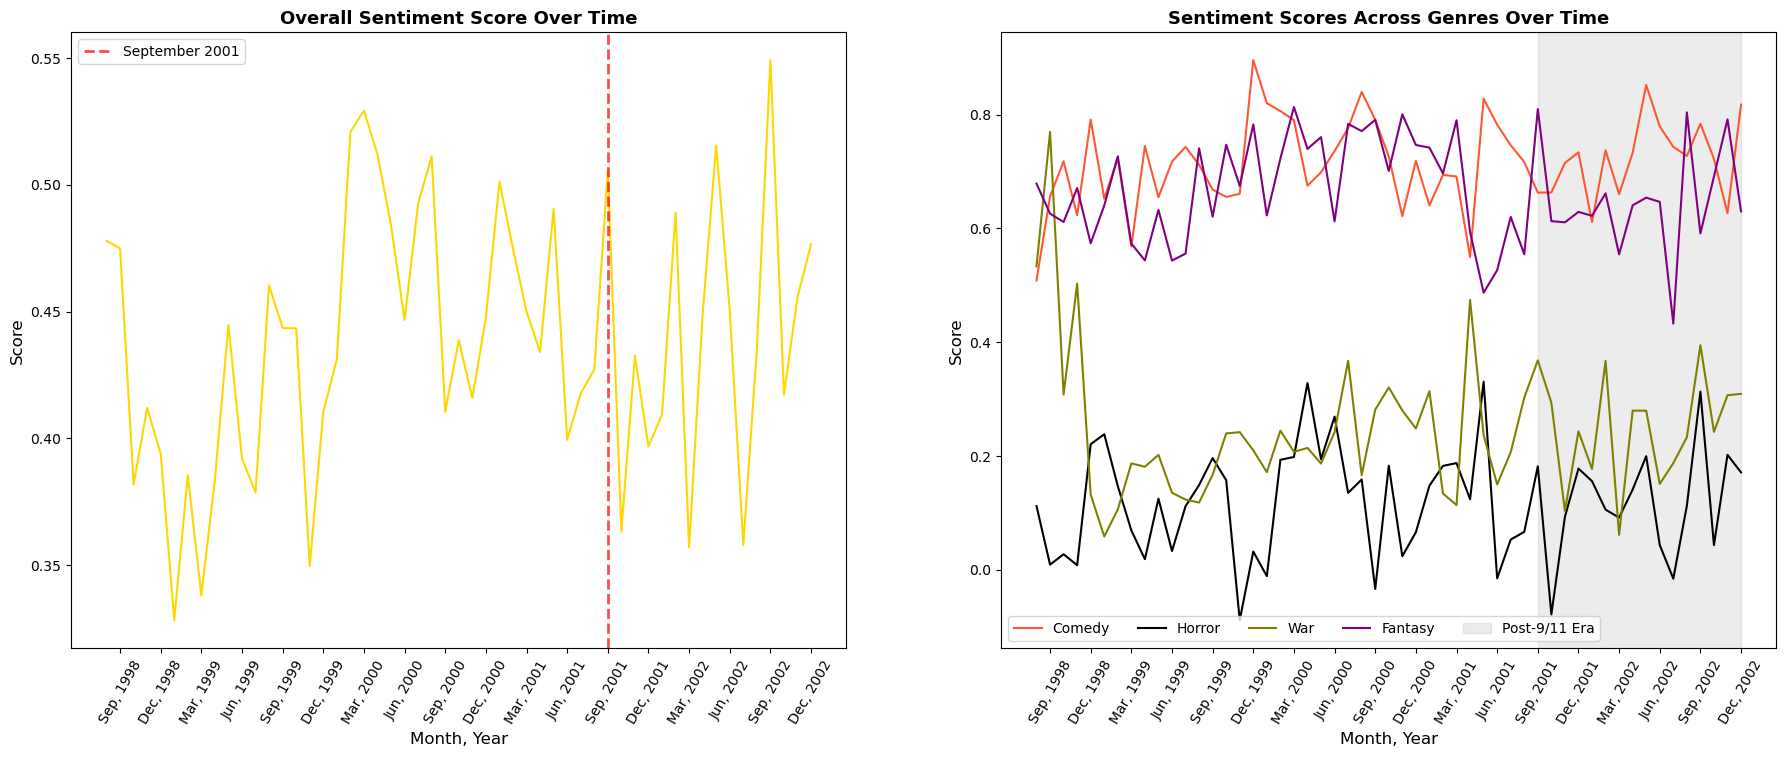

In [254]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))

ax1.plot(time_series['month'], time_series['score'], color = 'gold')
ax1.set_title('Overall Sentiment Score Over Time', size = 13, weight = "bold")
ax1.set_xlabel('Month, Year', size = 12)
ax1.set_ylabel('Score', size = 12)
ax1.set_xticks(time_series['month'][1::3])
ax1.tick_params(axis = 'x', rotation = 60)
ax1.axvline(x = 'Sep, 2001', color = 'red', linestyle = '--', linewidth=2, alpha=0.7, label = 'September 2001')
ax1.legend(loc = 'upper left')

# Second Graph
plot_data = time_series.set_index('month')[['Comedy', 'Horror', 'War', 'Fantasy']]

my_colors = ["#FF5733", "black", "olive", "purple"] # my colors
sns.lineplot(data = plot_data, ax = ax2, dashes = False, palette = my_colors) # , label = ['Comedy', 'Horror', 'War', 'Fantasy']
ax2.axvspan('Sep, 2001', 'Dec, 2002', color = 'gray', alpha = 0.15, label = 'Post-9/11 Era') # shading ,
ax2.legend(loc = 'lower left', ncol = 5) 
ax2.set_title("Sentiment Scores Across Genres Over Time", size = 13, weight = "bold")
ax2.set_xlabel('Month, Year', size = 12)
ax2.set_ylabel("Score", size = 12)
plt.xticks(rotation = 60)
ax2.set_xticks(time_series['month'][1::3]) # setting the ticks every three months, starting from the second value

# Shading the area from Sept 11 to the end of your data
# '2002-12-31' is an example end date

plt.show()

The first graph displays the overall mean sentiment score across all kinds of movies from August 1998 to December 2002, while the second one shows how sentiment for each genre evolves over the same period. Higher scores signify more positive perception, lower scores - more negative. As seen from the left chart, the overall review sentiment sharply dropped following September 2001, after which negativity lingered for a few months. Looking at the genre-specific visualization, all scores fell due to 9/11, with horror- and war-genred reviews reflecting the biggest decline in review sentiment. Interestingly, comedy and fantasy are regularly perceived more positively than war and horror.

/var/folders/xh/nk0kvhgx4xs4vzfmwkft2hpm0000gn/T/ipykernel_82702/2779829933.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  time_series['month'] = pd.to_datetime(time_series['month']) # Convert month to datetime so it sorts correctly
/var/folders/xh/nk0kvhgx4xs4vzfmwkft2hpm0000gn/T/ipykernel_82702/2779829933.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  time_series['month'] = pd.to_datetime(time_series['month']) # Convert month to datetime so it sorts correctly


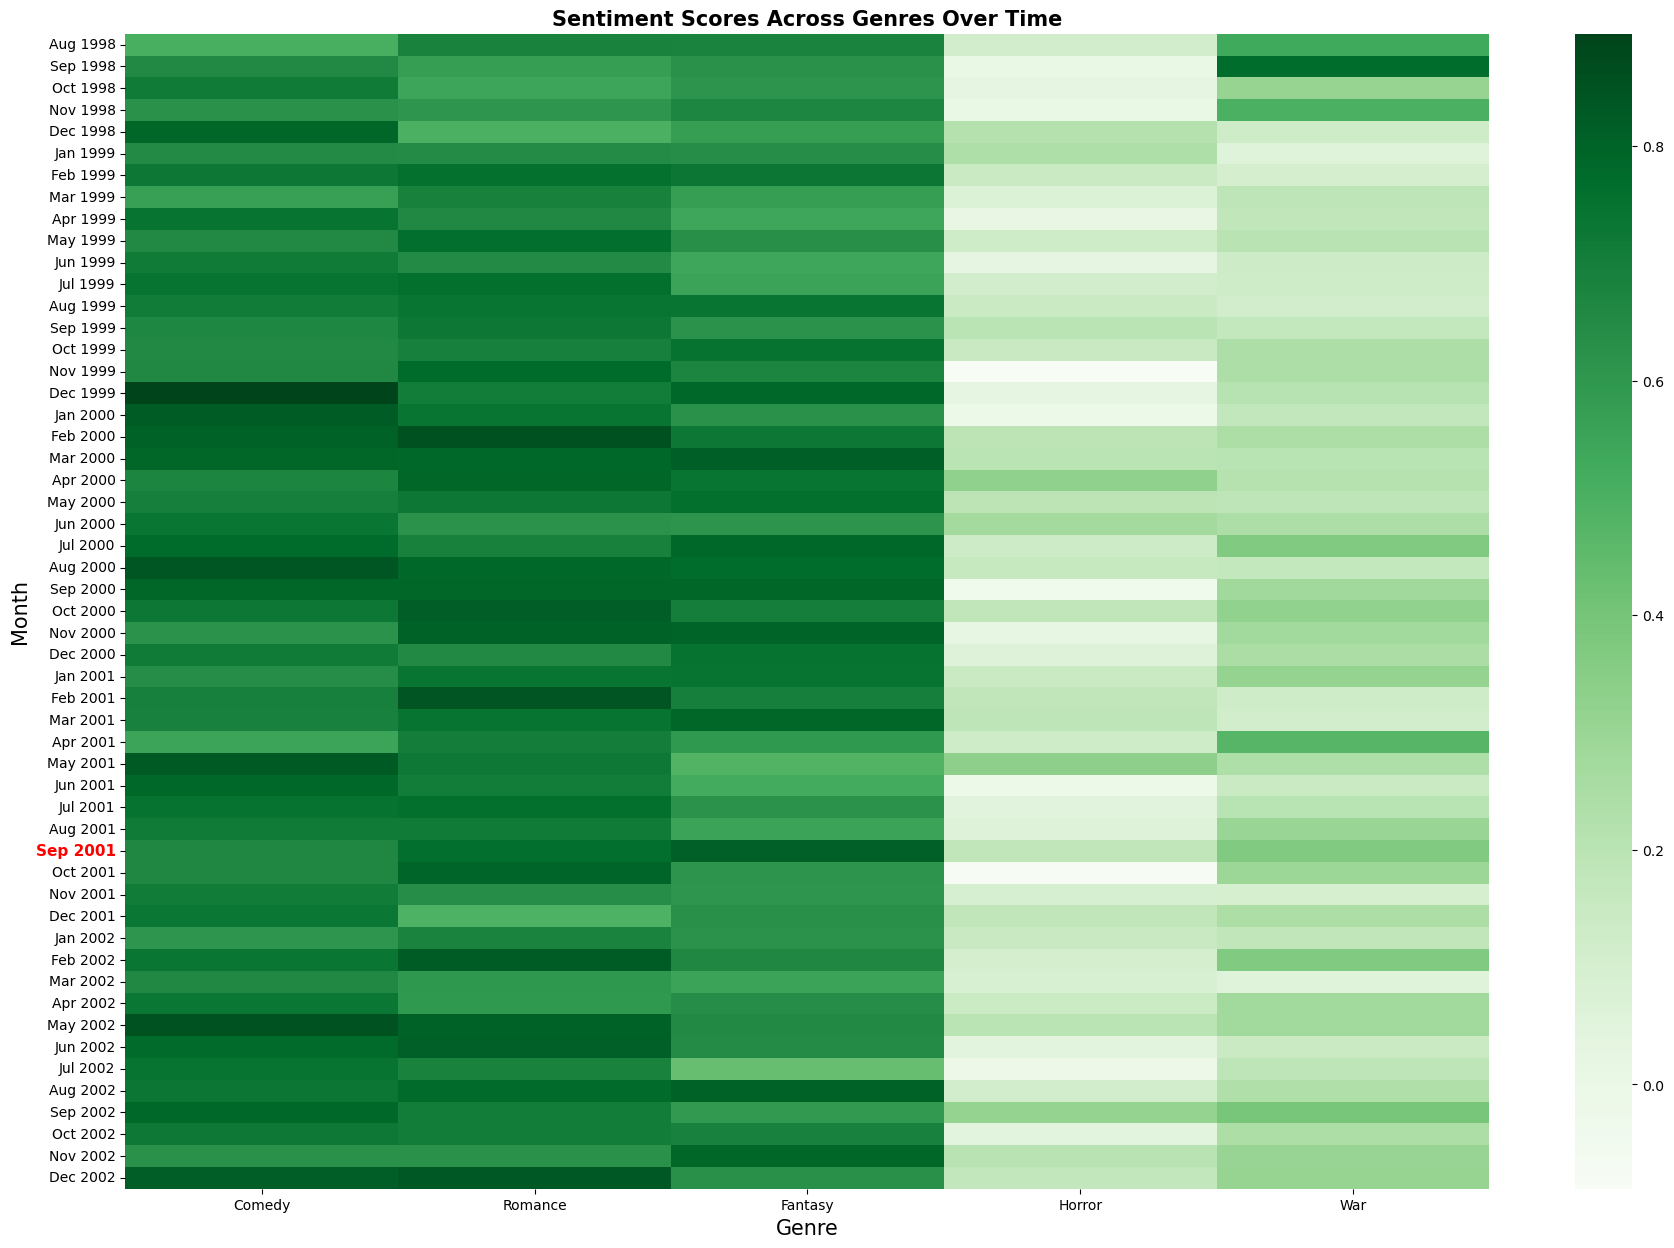

In [239]:
time_series['month'] = pd.to_datetime(time_series['month']) # Convert month to datetime so it sorts correctly
time_series = time_series.sort_values('month') 

# We'll format the date to look cleaner on the axis
plot_df = time_series.set_index(time_series['month'].dt.strftime('%b %Y'))
columns = ['Comedy', 'Romance', 'Fantasy', 'Horror', 'War']

plt.figure(figsize=(22, 15)) # Tall figure for many months 
ax = sns.heatmap(plot_df[columns], cmap = "Greens", annot = False) # - numerical values
ax.set_xticklabels(['Comedy', 'Romance', 'Fantasy', 'Horror', 'War'])
ax.set_ylabel('Month', fontsize = 15)
ax.set_xlabel('Genre', fontsize = 15)

for tick in ax.get_yticklabels():
    if tick.get_text() == "Sep 2001":
        tick.set_color("red")
        tick.set_weight("bold")
        tick.set_fontsize(11)
        
plt.title("Sentiment Scores Across Genres Over Time", weight = 'bold', fontsize = 15)
plt.show()